EDA DEL WORKSOP 2

In [332]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations


Se leen los csv de losd atos de los años para ver su contenido en esete ejemplo los vamos ahcer por años para mayor entendiemitno
de cada uno de manera indivudual 


csv año 2015

In [333]:
df_2015 = pd.read_csv('../data/raw/2015.csv', sep=",", encoding="utf-8")
df_2015

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176
...,...,...,...,...,...,...,...,...,...,...,...,...
153,Rwanda,Sub-Saharan Africa,154,3.465,0.03464,0.22208,0.77370,0.42864,0.59201,0.55191,0.22628,0.67042
154,Benin,Sub-Saharan Africa,155,3.340,0.03656,0.28665,0.35386,0.31910,0.48450,0.08010,0.18260,1.63328
155,Syria,Middle East and Northern Africa,156,3.006,0.05015,0.66320,0.47489,0.72193,0.15684,0.18906,0.47179,0.32858
156,Burundi,Sub-Saharan Africa,157,2.905,0.08658,0.01530,0.41587,0.22396,0.11850,0.10062,0.19727,1.83302


### Tamaño del dataset y los tipos de datos que haye ne el mismos

In [334]:
df_2015.shape

(158, 12)

EN el dastet del 2015 hay 158 datos con 12 columnas, ¿ que tipo de datos hay en las 12 columnas del dataset 

In [335]:
df_2015.dtypes

Country                           object
Region                            object
Happiness Rank                     int64
Happiness Score                  float64
Standard Error                   float64
Economy (GDP per Capita)         float64
Family                           float64
Health (Life Expectancy)         float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity                       float64
Dystopia Residual                float64
dtype: object

## limpieza de los de los datos 

### Datos nuelos 


In [336]:
df_2015.isnull().sum()

Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Standard Error                   0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64

En el daste no hay datos nulso en ninguna columna hay datos nulos 


### datos duplicados 

In [337]:
df_2015.duplicated().sum()

0

No hay datos duplicados en el dataset, lo que no es necesario la imputacion ni eliminacion de filas,


### datos categoricos


In [338]:
uniruqe_country_2015 = df_2015['Country'].unique()
uniruqe_country_2015

array(['Switzerland', 'Iceland', 'Denmark', 'Norway', 'Canada', 'Finland',
       'Netherlands', 'Sweden', 'New Zealand', 'Australia', 'Israel',
       'Costa Rica', 'Austria', 'Mexico', 'United States', 'Brazil',
       'Luxembourg', 'Ireland', 'Belgium', 'United Arab Emirates',
       'United Kingdom', 'Oman', 'Venezuela', 'Singapore', 'Panama',
       'Germany', 'Chile', 'Qatar', 'France', 'Argentina',
       'Czech Republic', 'Uruguay', 'Colombia', 'Thailand',
       'Saudi Arabia', 'Spain', 'Malta', 'Taiwan', 'Kuwait', 'Suriname',
       'Trinidad and Tobago', 'El Salvador', 'Guatemala', 'Uzbekistan',
       'Slovakia', 'Japan', 'South Korea', 'Ecuador', 'Bahrain', 'Italy',
       'Bolivia', 'Moldova', 'Paraguay', 'Kazakhstan', 'Slovenia',
       'Lithuania', 'Nicaragua', 'Peru', 'Belarus', 'Poland', 'Malaysia',
       'Croatia', 'Libya', 'Russia', 'Jamaica', 'North Cyprus', 'Cyprus',
       'Algeria', 'Kosovo', 'Turkmenistan', 'Mauritius', 'Hong Kong',
       'Estonia', 'Indonesi

In [339]:
df_2015['Country'].nunique()

158

In [340]:
uniruqe_region_2015= df_2015['Region'].unique()
uniruqe_region_2015

array(['Western Europe', 'North America', 'Australia and New Zealand',
       'Middle East and Northern Africa', 'Latin America and Caribbean',
       'Southeastern Asia', 'Central and Eastern Europe', 'Eastern Asia',
       'Sub-Saharan Africa', 'Southern Asia'], dtype=object)

Hasta el momento no es necrio una limpieza de doos datos en el dataset del año 2015, ya que losd astos esatn consistentes, lo siguiente sera ver del siguiente año del dataset

In [341]:
df_2015['Region'].nunique()

10

vamos aver que relcaiones tiene cada columna con la columan objetivo

In [342]:
numerical_cols_2015 = [
    'Happiness Score',
    'Standard Error',
    'Economy (GDP per Capita)',
    'Family',
    'Health (Life Expectancy)',
    'Freedom',
    'Trust (Government Corruption)',
    'Generosity',
    'Dystopia Residual'
]

df_numeric = df_2015[numerical_cols_2015]

correlation_matrix = df_numeric.corr(method='pearson')

happiness_correlations = correlation_matrix['Happiness Score'].sort_values(ascending=False)
print("\nCorrelaciones con Happiness Score:")
print(happiness_correlations)




Correlaciones con Happiness Score:
Happiness Score                  1.000000
Economy (GDP per Capita)         0.780966
Family                           0.740605
Health (Life Expectancy)         0.724200
Freedom                          0.568211
Dystopia Residual                0.530474
Trust (Government Corruption)    0.395199
Generosity                       0.180319
Standard Error                  -0.177254
Name: Happiness Score, dtype: float64


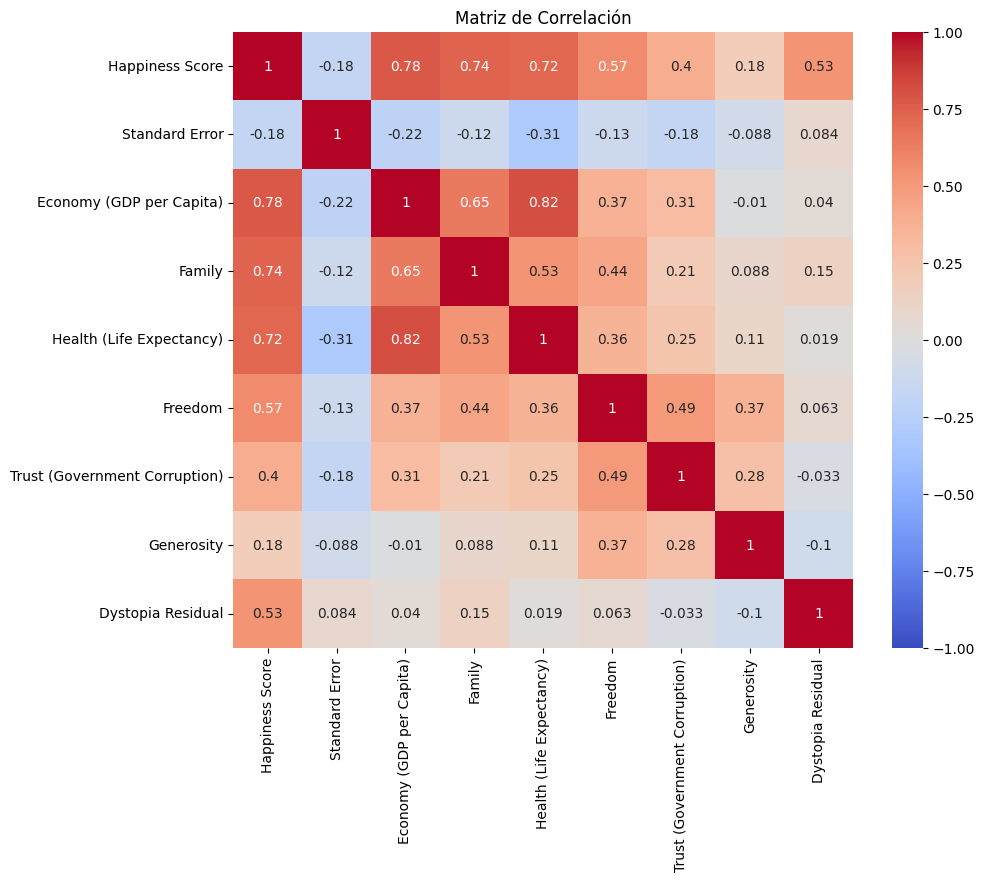

In [343]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Matriz de Correlación')
plt.show()

## dataset 2016

In [344]:
df_2016 = pd.read_csv('../data/raw/2016.csv', sep=",", encoding="utf-8")
df_2016

,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596
...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,Benin,Sub-Saharan Africa,153,3.484,3.404,3.564,0.39499,0.10419,0.21028,0.39747,0.06681,0.20180,2.10812
153,Afghanistan,Southern Asia,154,3.360,3.288,3.432,0.38227,0.11037,0.17344,0.16430,0.07112,0.31268,2.14558
154,Togo,Sub-Saharan Africa,155,3.303,3.192,3.414,0.28123,0.00000,0.24811,0.34678,0.11587,0.17517,2.13540
155,Syria,Middle East and Northern Africa,156,3.069,2.936,3.202,0.74719,0.14866,0.62994,0.06912,0.17233,0.48397,0.81789


Como vemos a diferencia del otro dataset, hay menos columnas,cuales columans faltan en el entrior datawet y cauales son iguales para detrmianr la columnas optimas para le modelo 

In [345]:
columnas_2015 = set(df_2015.columns)
columnas_2016 = set(df_2016.columns)

columnas_comunes = columnas_2015.intersection(columnas_2016)

columnas_solo_2015 = columnas_2015.difference(columnas_2016)

columnas_solo_2016 = columnas_2016.difference(columnas_2015)

print("Columnas comunes:", columnas_comunes)
print("Columnas solo en df_2015:", columnas_solo_2015)
print("Columnas solo en df_2016:", columnas_solo_2016)

Columnas comunes: {'Happiness Rank', 'Economy (GDP per Capita)', 'Trust (Government Corruption)', 'Happiness Score', 'Health (Life Expectancy)', 'Country', 'Freedom', 'Generosity', 'Region', 'Family', 'Dystopia Residual'}
Columnas solo en df_2015: {'Standard Error'}
Columnas solo en df_2016: {'Lower Confidence Interval', 'Upper Confidence Interval'}


### Tamalñao del dataset y los tipos de datos que haye ne el mismos

In [346]:
df_2016.shape

(157, 13)

In [347]:
df_2016.dtypes

Country                           object
Region                            object
Happiness Rank                     int64
Happiness Score                  float64
Lower Confidence Interval        float64
Upper Confidence Interval        float64
Economy (GDP per Capita)         float64
Family                           float64
Health (Life Expectancy)         float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity                       float64
Dystopia Residual                float64
dtype: object

In [348]:
df_2016.isnull().sum()

Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Lower Confidence Interval        0
Upper Confidence Interval        0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64

In [349]:
df_2016.duplicated().sum()

0

### datos categoricos

In [350]:
uniruqe_country_2016 = df_2016['Country'].unique()
uniruqe_country_2016

array(['Denmark', 'Switzerland', 'Iceland', 'Norway', 'Finland', 'Canada',
       'Netherlands', 'New Zealand', 'Australia', 'Sweden', 'Israel',
       'Austria', 'United States', 'Costa Rica', 'Puerto Rico', 'Germany',
       'Brazil', 'Belgium', 'Ireland', 'Luxembourg', 'Mexico',
       'Singapore', 'United Kingdom', 'Chile', 'Panama', 'Argentina',
       'Czech Republic', 'United Arab Emirates', 'Uruguay', 'Malta',
       'Colombia', 'France', 'Thailand', 'Saudi Arabia', 'Taiwan',
       'Qatar', 'Spain', 'Algeria', 'Guatemala', 'Suriname', 'Kuwait',
       'Bahrain', 'Trinidad and Tobago', 'Venezuela', 'Slovakia',
       'El Salvador', 'Malaysia', 'Nicaragua', 'Uzbekistan', 'Italy',
       'Ecuador', 'Belize', 'Japan', 'Kazakhstan', 'Moldova', 'Russia',
       'Poland', 'South Korea', 'Bolivia', 'Lithuania', 'Belarus',
       'North Cyprus', 'Slovenia', 'Peru', 'Turkmenistan', 'Mauritius',
       'Libya', 'Latvia', 'Cyprus', 'Paraguay', 'Romania', 'Estonia',
       'Jamaica', 'Croa

In [351]:
df_2016['Country'].nunique()

157

In [352]:
uniruqe_region_2016 = df_2016['Region'].unique()
uniruqe_region_2016

array(['Western Europe', 'North America', 'Australia and New Zealand',
       'Middle East and Northern Africa', 'Latin America and Caribbean',
       'Southeastern Asia', 'Central and Eastern Europe', 'Eastern Asia',
       'Sub-Saharan Africa', 'Southern Asia'], dtype=object)

In [353]:
df_2016['Region'].nunique()

10

In [354]:
numerical_cols_2016= [
    'Happiness Score',
    'Lower Confidence Interval',
    'Upper Confidence Interval',
    'Economy (GDP per Capita)',
    'Family',
    'Health (Life Expectancy)',
    'Freedom',
    'Trust (Government Corruption)',
    'Generosity',
    'Dystopia Residual'
]

df_numeric = df_2016[numerical_cols_2016]

correlation_matrix = df_numeric.corr(method='pearson')

happiness_correlations = correlation_matrix['Happiness Score'].sort_values(ascending=False)
print("\nCorrelaciones con Happiness Score:")
print(happiness_correlations)



Correlaciones con Happiness Score:
Happiness Score                  1.000000
Lower Confidence Interval        0.999485
Upper Confidence Interval        0.999474
Economy (GDP per Capita)         0.790322
Health (Life Expectancy)         0.765384
Family                           0.739252
Freedom                          0.566827
Dystopia Residual                0.543738
Trust (Government Corruption)    0.402032
Generosity                       0.156848
Name: Happiness Score, dtype: float64


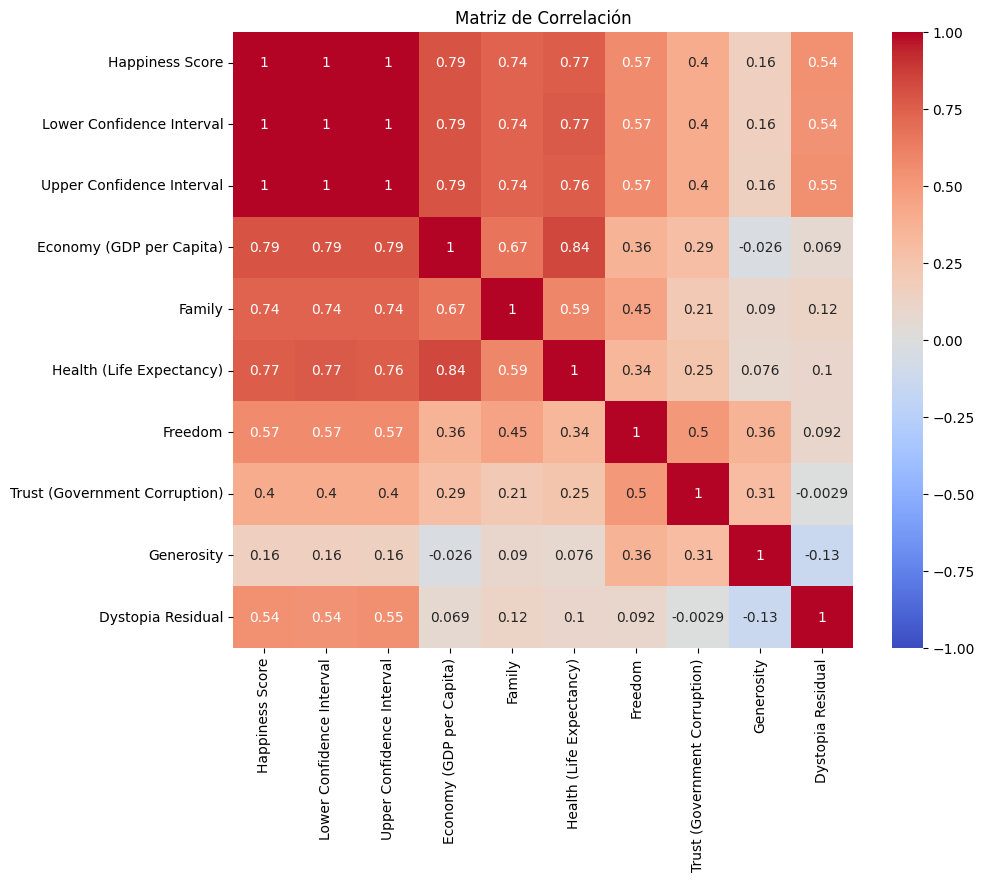

In [355]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Matriz de Correlación')
plt.show()

## 2017

In [356]:
df_2017 = pd.read_csv('../data/raw/2016.csv', sep=",", encoding="utf-8")
df_2017

,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596
...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,Benin,Sub-Saharan Africa,153,3.484,3.404,3.564,0.39499,0.10419,0.21028,0.39747,0.06681,0.20180,2.10812
153,Afghanistan,Southern Asia,154,3.360,3.288,3.432,0.38227,0.11037,0.17344,0.16430,0.07112,0.31268,2.14558
154,Togo,Sub-Saharan Africa,155,3.303,3.192,3.414,0.28123,0.00000,0.24811,0.34678,0.11587,0.17517,2.13540
155,Syria,Middle East and Northern Africa,156,3.069,2.936,3.202,0.74719,0.14866,0.62994,0.06912,0.17233,0.48397,0.81789


In [357]:
df_2017.shape

(157, 13)

In [358]:
df_2017.dtypes

Country                           object
Region                            object
Happiness Rank                     int64
Happiness Score                  float64
Lower Confidence Interval        float64
Upper Confidence Interval        float64
Economy (GDP per Capita)         float64
Family                           float64
Health (Life Expectancy)         float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity                       float64
Dystopia Residual                float64
dtype: object

In [359]:
df_2017.isnull().sum()

Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Lower Confidence Interval        0
Upper Confidence Interval        0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64

In [360]:
df_2017.duplicated().sum()

0

In [361]:
uniruqe_country_2017 = df_2017['Country'].unique()
uniruqe_country_2017

array(['Denmark', 'Switzerland', 'Iceland', 'Norway', 'Finland', 'Canada',
       'Netherlands', 'New Zealand', 'Australia', 'Sweden', 'Israel',
       'Austria', 'United States', 'Costa Rica', 'Puerto Rico', 'Germany',
       'Brazil', 'Belgium', 'Ireland', 'Luxembourg', 'Mexico',
       'Singapore', 'United Kingdom', 'Chile', 'Panama', 'Argentina',
       'Czech Republic', 'United Arab Emirates', 'Uruguay', 'Malta',
       'Colombia', 'France', 'Thailand', 'Saudi Arabia', 'Taiwan',
       'Qatar', 'Spain', 'Algeria', 'Guatemala', 'Suriname', 'Kuwait',
       'Bahrain', 'Trinidad and Tobago', 'Venezuela', 'Slovakia',
       'El Salvador', 'Malaysia', 'Nicaragua', 'Uzbekistan', 'Italy',
       'Ecuador', 'Belize', 'Japan', 'Kazakhstan', 'Moldova', 'Russia',
       'Poland', 'South Korea', 'Bolivia', 'Lithuania', 'Belarus',
       'North Cyprus', 'Slovenia', 'Peru', 'Turkmenistan', 'Mauritius',
       'Libya', 'Latvia', 'Cyprus', 'Paraguay', 'Romania', 'Estonia',
       'Jamaica', 'Croa

In [362]:
df_2017['Country'].nunique()

157

In [363]:
uniruqe_region_2017 = df_2017['Region'].unique()
uniruqe_region_2017

array(['Western Europe', 'North America', 'Australia and New Zealand',
       'Middle East and Northern Africa', 'Latin America and Caribbean',
       'Southeastern Asia', 'Central and Eastern Europe', 'Eastern Asia',
       'Sub-Saharan Africa', 'Southern Asia'], dtype=object)

In [364]:
df_2017['Region'].nunique()

10

In [365]:
numerical_cols_2017= [
   'Happiness Score',
   'Lower Confidence Interval',
   'Upper Confidence Interval',
   'Economy (GDP per Capita)',
   'Family',
   'Health (Life Expectancy)',
   'Freedom',
   'Trust (Government Corruption)',
   'Generosity',
   'Dystopia Residual'
]


df_numeric = df_2017[numerical_cols_2017]

correlation_matrix = df_numeric.corr(method='pearson')

happiness_correlations = correlation_matrix['Happiness Score'].sort_values(ascending=False)
print("\nCorrelaciones con Happiness Score:")
print(happiness_correlations)


Correlaciones con Happiness Score:
Happiness Score                  1.000000
Lower Confidence Interval        0.999485
Upper Confidence Interval        0.999474
Economy (GDP per Capita)         0.790322
Health (Life Expectancy)         0.765384
Family                           0.739252
Freedom                          0.566827
Dystopia Residual                0.543738
Trust (Government Corruption)    0.402032
Generosity                       0.156848
Name: Happiness Score, dtype: float64


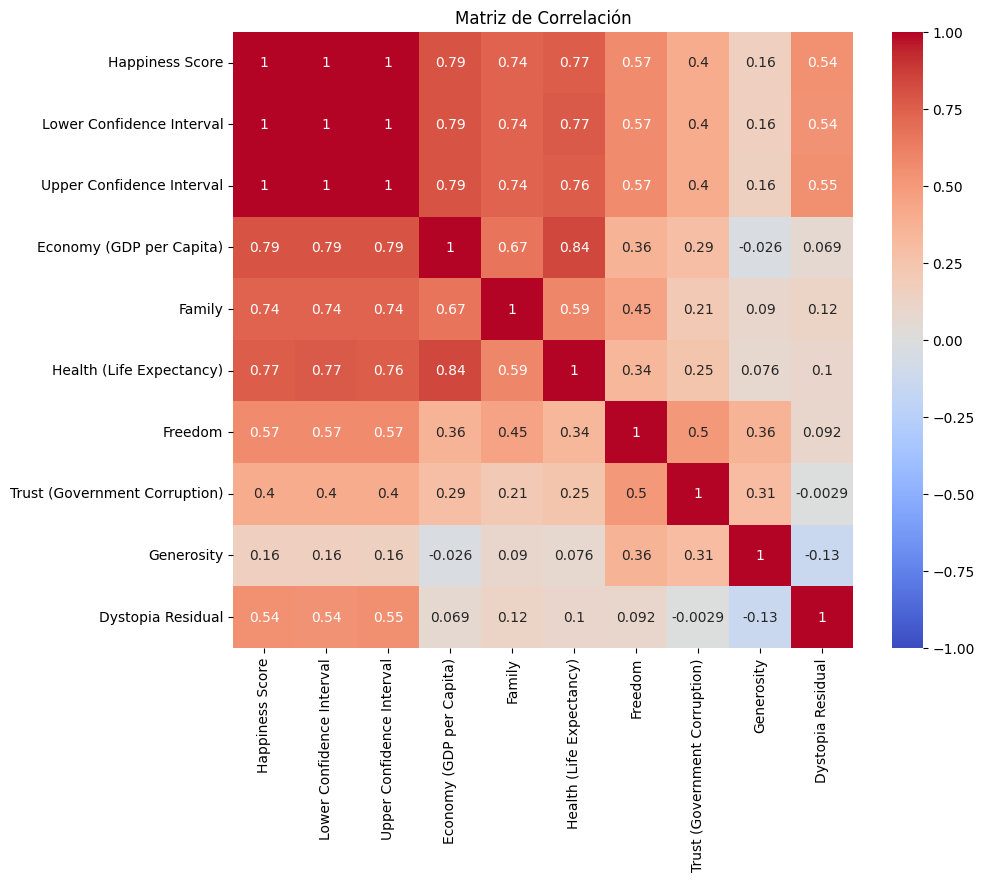

In [366]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Matriz de Correlación')
plt.show()

## 2018

In [367]:
df_2018 = pd.read_csv('../data/raw/2018.csv', sep=",", encoding="utf-8")
df_2018

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.632,1.305,1.592,0.874,0.681,0.202,0.393
1,2,Norway,7.594,1.456,1.582,0.861,0.686,0.286,0.340
2,3,Denmark,7.555,1.351,1.590,0.868,0.683,0.284,0.408
3,4,Iceland,7.495,1.343,1.644,0.914,0.677,0.353,0.138
4,5,Switzerland,7.487,1.420,1.549,0.927,0.660,0.256,0.357
...,...,...,...,...,...,...,...,...,...
151,152,Yemen,3.355,0.442,1.073,0.343,0.244,0.083,0.064
152,153,Tanzania,3.303,0.455,0.991,0.381,0.481,0.270,0.097
153,154,South Sudan,3.254,0.337,0.608,0.177,0.112,0.224,0.106
154,155,Central African Republic,3.083,0.024,0.000,0.010,0.305,0.218,0.038


In [368]:
df_2018.shape

(156, 9)

In [369]:
df_2018.dtypes

Overall rank                      int64
Country or region                object
Score                           float64
GDP per capita                  float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
dtype: object

In [370]:
df_2018.isnull().sum()

Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       1
dtype: int64

Cual fila es la que east nula ? en la olumna de Perceptions of curruption hay un valor nulos, como se va a atrratara este nulo ?

In [371]:
df_2018.duplicated().sum()

0

In [372]:
uniruqe_country_2018 = df_2018['Country or region'].unique()
uniruqe_country_2018

array(['Finland', 'Norway', 'Denmark', 'Iceland', 'Switzerland',
       'Netherlands', 'Canada', 'New Zealand', 'Sweden', 'Australia',
       'United Kingdom', 'Austria', 'Costa Rica', 'Ireland', 'Germany',
       'Belgium', 'Luxembourg', 'United States', 'Israel',
       'United Arab Emirates', 'Czech Republic', 'Malta', 'France',
       'Mexico', 'Chile', 'Taiwan', 'Panama', 'Brazil', 'Argentina',
       'Guatemala', 'Uruguay', 'Qatar', 'Saudi Arabia', 'Singapore',
       'Malaysia', 'Spain', 'Colombia', 'Trinidad & Tobago', 'Slovakia',
       'El Salvador', 'Nicaragua', 'Poland', 'Bahrain', 'Uzbekistan',
       'Kuwait', 'Thailand', 'Italy', 'Ecuador', 'Belize', 'Lithuania',
       'Slovenia', 'Romania', 'Latvia', 'Japan', 'Mauritius', 'Jamaica',
       'South Korea', 'Northern Cyprus', 'Russia', 'Kazakhstan', 'Cyprus',
       'Bolivia', 'Estonia', 'Paraguay', 'Peru', 'Kosovo', 'Moldova',
       'Turkmenistan', 'Hungary', 'Libya', 'Philippines', 'Honduras',
       'Belarus', 'Turkey

In [373]:
df_2018['Country or region'].nunique()

156

En este dateet no se esucnedta region, este debemos de impouatar la region o caso eleiminar esat columna de losd emas dastet, este importange para la toma de deciones

In [374]:
numerical_cols_2018= [
   'Score',
   'GDP per capita',
   'Social support',
   'Healthy life expectancy',
   'Freedom to make life choices',
   'Generosity',
   'Perceptions of corruption'
]


df_numeric = df_2018[numerical_cols_2018]

correlation_matrix = df_numeric.corr(method='pearson')

happiness_correlations = correlation_matrix['Score'].sort_values(ascending=False)
print("\nCorrelaciones con Happiness Score:")
print(happiness_correlations)


Correlaciones con Happiness Score:
Score                           1.000000
GDP per capita                  0.802124
Healthy life expectancy         0.775814
Social support                  0.745760
Freedom to make life choices    0.544280
Perceptions of corruption       0.405292
Generosity                      0.135825
Name: Score, dtype: float64


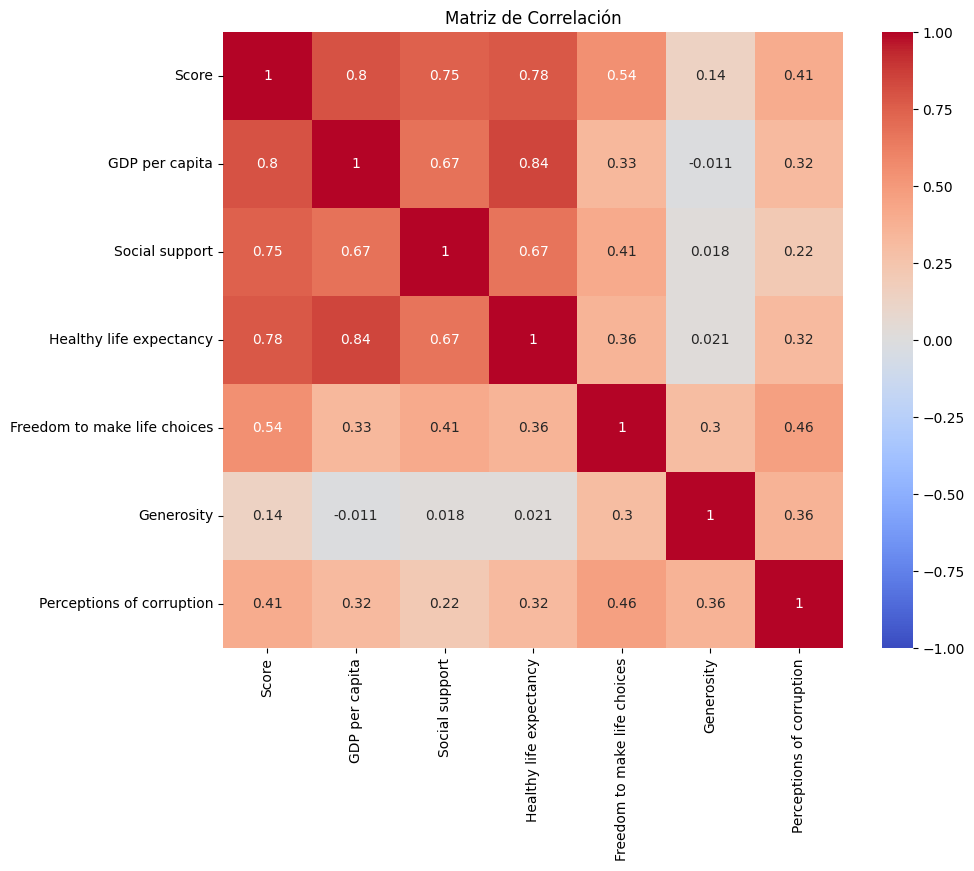

In [375]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Matriz de Correlación')
plt.show()

## 2019

In [376]:
df_2019 = pd.read_csv('../data/raw/2019.csv', sep=",", encoding="utf-8")
df_2019

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
...,...,...,...,...,...,...,...,...,...
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035


In [377]:
df_2019.shape

(156, 9)

In [378]:
df_2019.dtypes

Overall rank                      int64
Country or region                object
Score                           float64
GDP per capita                  float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
dtype: object

In [379]:
df_2019.isnull().sum()

Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64

In [380]:
df_2019.duplicated().sum()

0

In [381]:
uniruqe_country_2019= df_2019['Country or region'].unique()
uniruqe_country_2019

array(['Finland', 'Denmark', 'Norway', 'Iceland', 'Netherlands',
       'Switzerland', 'Sweden', 'New Zealand', 'Canada', 'Austria',
       'Australia', 'Costa Rica', 'Israel', 'Luxembourg',
       'United Kingdom', 'Ireland', 'Germany', 'Belgium', 'United States',
       'Czech Republic', 'United Arab Emirates', 'Malta', 'Mexico',
       'France', 'Taiwan', 'Chile', 'Guatemala', 'Saudi Arabia', 'Qatar',
       'Spain', 'Panama', 'Brazil', 'Uruguay', 'Singapore', 'El Salvador',
       'Italy', 'Bahrain', 'Slovakia', 'Trinidad & Tobago', 'Poland',
       'Uzbekistan', 'Lithuania', 'Colombia', 'Slovenia', 'Nicaragua',
       'Kosovo', 'Argentina', 'Romania', 'Cyprus', 'Ecuador', 'Kuwait',
       'Thailand', 'Latvia', 'South Korea', 'Estonia', 'Jamaica',
       'Mauritius', 'Japan', 'Honduras', 'Kazakhstan', 'Bolivia',
       'Hungary', 'Paraguay', 'Northern Cyprus', 'Peru', 'Portugal',
       'Pakistan', 'Russia', 'Philippines', 'Serbia', 'Moldova', 'Libya',
       'Montenegro', 'Tajikis

In [382]:
df_2019['Country or region'].nunique()

156

In [383]:
numerical_cols_2019= [
   'Score',
   'GDP per capita',
   'Social support',
   'Healthy life expectancy',
   'Freedom to make life choices',
   'Generosity',
   'Perceptions of corruption'
]


df_numeric = df_2019[numerical_cols_2019]

correlation_matrix = df_numeric.corr(method='pearson')

happiness_correlations = correlation_matrix['Score'].sort_values(ascending=False)
print("\nCorrelaciones con Happiness Score:")
print(happiness_correlations)


Correlaciones con Happiness Score:
Score                           1.000000
GDP per capita                  0.793883
Healthy life expectancy         0.779883
Social support                  0.777058
Freedom to make life choices    0.566742
Perceptions of corruption       0.385613
Generosity                      0.075824
Name: Score, dtype: float64


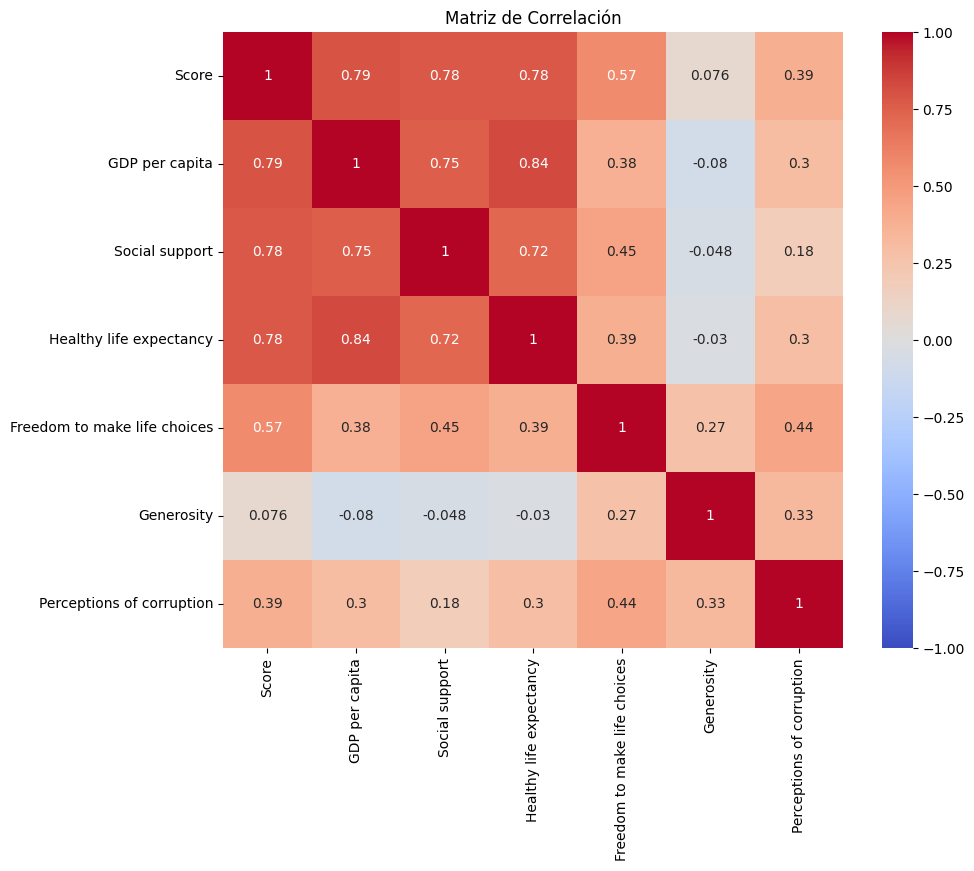

In [384]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Matriz de Correlación')
plt.show()

#### Unir los dataset

En este dateet no se esucnedta region, este debemos de impouatar la region o caso eleiminar esat columna de losd emas dastet, este importange para la toma de deciones

In [385]:
dataframes= {
    "2015": df_2015,
    "2016": df_2016,
    "2017": df_2017,
    "2018": df_2018,
    "2019": df_2019
}

conjuntos_columnas = [set(df.columns) for df in dataframes.values()]

columnas_comunes_todos = set.intersection(*conjuntos_columnas)

print("Columnas comunes en los 5 datasets:")
print(columnas_comunes_todos)


Columnas comunes en los 5 datasets:
{'Generosity'}


Segun lo anterior la unica columna que tinene en comun los dastet este Genorosity, a lo que debemosexaminar cada columna detenimanete para saber que columnas vamos  aescoger, teniendo en encuneta que es para neterenar un modelo para la medidad de feliciada 

In [386]:

for (name1, df1), (name2, df2) in combinations(dataframes.items(), 2):
    columnas_1 = set(df1.columns)
    columnas_2 = set(df2.columns)
    
    comunes = columnas_1.intersection(columnas_2)
    solo_1 = columnas_1.difference(columnas_2)
    solo_2 = columnas_2.difference(columnas_1)
    
    print(f"--- Comparación entre {name1} y {name2} ---")
    print("Columnas comunes:", comunes)
    print(f"Columnas solo en {name1}:", solo_1)
    print(f"Columnas solo en {name2}:", solo_2)
    print("\n")

--- Comparación entre 2015 y 2016 ---
Columnas comunes: {'Happiness Rank', 'Economy (GDP per Capita)', 'Trust (Government Corruption)', 'Happiness Score', 'Health (Life Expectancy)', 'Country', 'Freedom', 'Generosity', 'Region', 'Family', 'Dystopia Residual'}
Columnas solo en 2015: {'Standard Error'}
Columnas solo en 2016: {'Lower Confidence Interval', 'Upper Confidence Interval'}


--- Comparación entre 2015 y 2017 ---
Columnas comunes: {'Happiness Rank', 'Economy (GDP per Capita)', 'Trust (Government Corruption)', 'Happiness Score', 'Health (Life Expectancy)', 'Country', 'Freedom', 'Generosity', 'Region', 'Family', 'Dystopia Residual'}
Columnas solo en 2015: {'Standard Error'}
Columnas solo en 2017: {'Lower Confidence Interval', 'Upper Confidence Interval'}


--- Comparación entre 2015 y 2018 ---
Columnas comunes: {'Generosity'}
Columnas solo en 2015: {'Happiness Rank', 'Economy (GDP per Capita)', 'Trust (Government Corruption)', 'Happiness Score', 'Health (Life Expectancy)', 'Countr

De lo anterior podemos decir que ... un indicio puede seer en que los sultimos dastettiene relacionen lqa columnasy los 3 preimeros tine las miasm columnas, vamos a realizar el codifo para verficar esto 

In [387]:
dataframes= {
    "2015": df_2015,
    "2016": df_2016,
    "2017": df_2017,
}

conjuntos_columnas = [set(df.columns) for df in dataframes.values()]

columnas_comunes_todos = set.intersection(*conjuntos_columnas)

print("Columnas comunes en los 5 datasets:")
print(columnas_comunes_todos)

Columnas comunes en los 5 datasets:
{'Happiness Rank', 'Economy (GDP per Capita)', 'Trust (Government Corruption)', 'Happiness Score', 'Health (Life Expectancy)', 'Country', 'Freedom', 'Generosity', 'Region', 'Family', 'Dystopia Residual'}


como vemos en los 3 priemros dastet exsiten estas columnas en comun, esto es buneo ya que podemos armar un dastet unificado para estamos 3 daste, ahora vieen vamos a organizar los 2 ultimos  ... 

In [388]:
dataframes= {
    "2018": df_2018,
    "2019": df_2019
}

conjuntos_columnas = [set(df.columns) for df in dataframes.values()]

columnas_comunes_todos = set.intersection(*conjuntos_columnas)

print("Columnas comunes en los 5 datasets:")
print(columnas_comunes_todos)

Columnas comunes en los 5 datasets:
{'Healthy life expectancy', 'Social support', 'GDP per capita', 'Freedom to make life choices', 'Generosity', 'Overall rank', 'Score', 'Perceptions of corruption', 'Country or region'}


todas esats columnas teinen en comun estos dso dataset, ahoara vcomapros los dos resulatdo anetriores apra determinar quwwe columnas son necarios, teniendo en cunta la primisa de tener la maxima cantidad de datos posibles. 


In [389]:
print(df_2015.columns)
print(df_2016.columns)
print(df_2017.columns)
print(df_2018.columns)
print(df_2019.columns)

Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
       'Standard Error', 'Economy (GDP per Capita)', 'Family',
       'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)',
       'Generosity', 'Dystopia Residual'],
      dtype='object')
Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
       'Lower Confidence Interval', 'Upper Confidence Interval',
       'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)',
       'Freedom', 'Trust (Government Corruption)', 'Generosity',
       'Dystopia Residual'],
      dtype='object')
Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
       'Lower Confidence Interval', 'Upper Confidence Interval',
       'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)',
       'Freedom', 'Trust (Government Corruption)', 'Generosity',
       'Dystopia Residual'],
      dtype='object')
Index(['Overall rank', 'Country or region', 'Score', 'GDP per capita',
       'Social supp

In [390]:

column_rename_map = {
    'Country or region': 'Country',
    'Overall rank': 'Happiness Rank',
    'Score': 'Happiness Score',
    'GDP per capita': 'Economy (GDP per Capita)',
    'Social support': 'Family',
    'Healthy life expectancy': 'Health (Life Expectancy)',
    'Freedom to make life choices': 'Freedom',
    'Perceptions of corruption': 'Trust (Government Corruption)'
}

df_2018 = df_2018.rename(columns=column_rename_map)
df_2019 = df_2019.rename(columns=column_rename_map)


In [391]:
dataframes = {
    '2015': df_2015,
    '2016': df_2016,
    '2017': df_2017,
    '2018': df_2018,
    '2019': df_2019
}

conjuntos_columnas = [set(df.columns) for df in dataframes.values()]
columnas_comunes= set.intersection(*conjuntos_columnas)

print("Columnas comunes en los 5 datasets:")
print(columnas_comunes)


Columnas comunes en los 5 datasets:
{'Happiness Rank', 'Economy (GDP per Capita)', 'Trust (Government Corruption)', 'Happiness Score', 'Health (Life Expectancy)', 'Country', 'Freedom', 'Generosity', 'Family'}


Conestos dastet ya estadatarizado vmoas a crear stedate by rreliazar la repsectiva limpieza, tener en cuenta la exploracion de losd datos que hemos venido haciendo 

In [392]:
dfs_filtrados = []

for año, df in dataframes.items():
    df_filtrado = df[list(columnas_comunes)].copy() 
    df_filtrado['Year'] = int(año)  
    dfs_filtrados.append(df_filtrado)



df_unido = pd.concat(dfs_filtrados, ignore_index=True)


In [393]:
print(df_unido.head())
print(df_unido.columns)
print(df_unido.shape)


   Happiness Rank  Economy (GDP per Capita)  Trust (Government Corruption)  \
0               1                   1.39651                        0.41978   
1               2                   1.30232                        0.14145   
2               3                   1.32548                        0.48357   
3               4                   1.45900                        0.36503   
4               5                   1.32629                        0.32957   

   Happiness Score  Health (Life Expectancy)      Country  Freedom  \
0            7.587                   0.94143  Switzerland  0.66557   
1            7.561                   0.94784      Iceland  0.62877   
2            7.527                   0.87464      Denmark  0.64938   
3            7.522                   0.88521       Norway  0.66973   
4            7.427                   0.90563       Canada  0.63297   

   Generosity   Family  Year  
0     0.29678  1.34951  2015  
1     0.43630  1.40223  2015  
2     0.34139  1.

In [394]:
df_unido.dtypes

Happiness Rank                     int64
Economy (GDP per Capita)         float64
Trust (Government Corruption)    float64
Happiness Score                  float64
Health (Life Expectancy)         float64
Country                           object
Freedom                          float64
Generosity                       float64
Family                           float64
Year                               int64
dtype: object

In [395]:
df_unido.isnull().sum()

Happiness Rank                   0
Economy (GDP per Capita)         0
Trust (Government Corruption)    1
Happiness Score                  0
Health (Life Expectancy)         0
Country                          0
Freedom                          0
Generosity                       0
Family                           0
Year                             0
dtype: int64

In [396]:
df_unido = df_unido.dropna()


In [397]:
df_2018.duplicated().sum()

0

In [398]:
df_unido.shape

(783, 10)

Con el daset unido podemos hacer las grficas y el nalaisis descritvo de la dastet 

In [399]:
df_unido.describe().T

,count,mean,std,min,25%,50%,75%,max
Happiness Rank,783.0,78.968072,45.275121,1.000,40.000000,79.00000,118.000000,158.00000
Economy (GDP per Capita),783.0,0.908532,0.402889,0.000,0.611510,0.97438,1.230555,1.82427
Trust (Government Corruption),783.0,0.128338,0.107764,0.000,0.054500,0.09314,0.161800,0.55191
Happiness Score,783.0,5.382820,1.129122,2.839,4.503500,5.33200,6.208500,7.76900
Health (Life Expectancy),783.0,0.613445,0.246701,0.000,0.440305,0.64718,0.808000,1.14100
Freedom,783.0,0.403670,0.152909,0.000,0.305000,0.41900,0.524500,0.72400
Generosity,783.0,0.217838,0.122026,0.000,0.130000,0.20180,0.275355,0.81971
Family,783.0,0.999804,0.337583,0.000,0.790425,1.03143,1.240090,1.64400
Year,783.0,2016.992337,1.416000,2015.000,2016.000000,2017.00000,2018.000000,2019.00000


In [400]:
df_unido.describe(include='object').T

,count,unique,top,freq
Country,783,168,Switzerland,5


In [401]:
numerical_cols = df_unido.select_dtypes(include=['int64', 'float64'])


for col in numerical_cols:
    print(f"\n--- Handling Outliers for {col} ---")

    Q1 = df_unido[col].quantile(0.25)
    Q3 = df_unido[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df_unido[(df_unido[col] < lower_limit) | (df_unido[col] > upper_limit)]
    print(f"Number of Outliers: {len(outliers)}")


--- Handling Outliers for Happiness Rank ---
Number of Outliers: 0

--- Handling Outliers for Economy (GDP per Capita) ---
Number of Outliers: 0

--- Handling Outliers for Trust (Government Corruption) ---
Number of Outliers: 60

--- Handling Outliers for Happiness Score ---
Number of Outliers: 0

--- Handling Outliers for Health (Life Expectancy) ---
Number of Outliers: 0

--- Handling Outliers for Freedom ---
Number of Outliers: 0

--- Handling Outliers for Generosity ---
Number of Outliers: 23

--- Handling Outliers for Family ---
Number of Outliers: 9

--- Handling Outliers for Year ---
Number of Outliers: 0


Visua

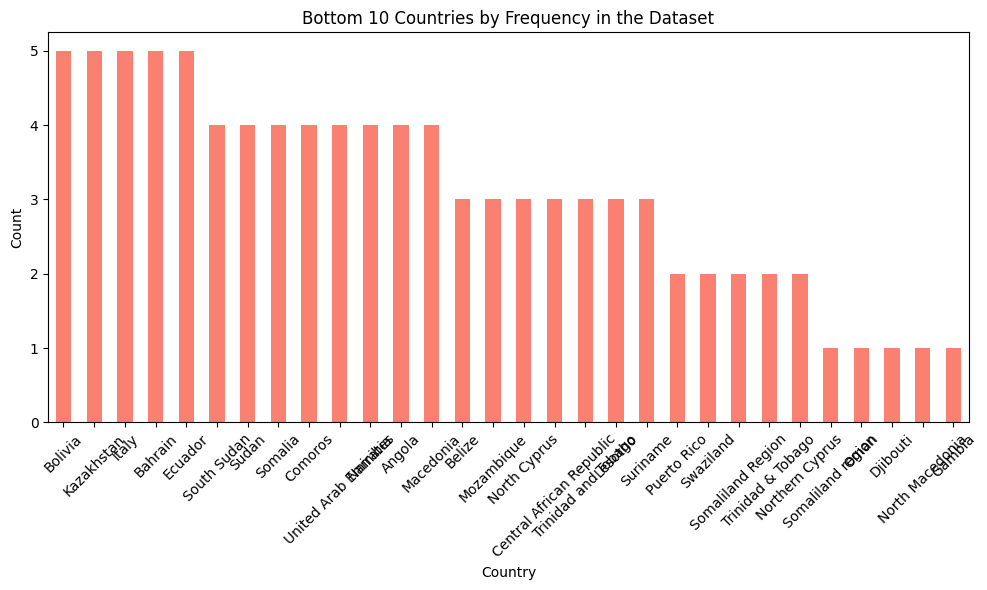

In [402]:

conteo_paises = df_unido['Country'].value_counts()

ultimos_10 = conteo_paises.tail(30)

ultimos_10.plot(kind='bar', figsize=(10, 6), color='salmon')
plt.title('Bottom 10 Countries by Frequency in the Dataset')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


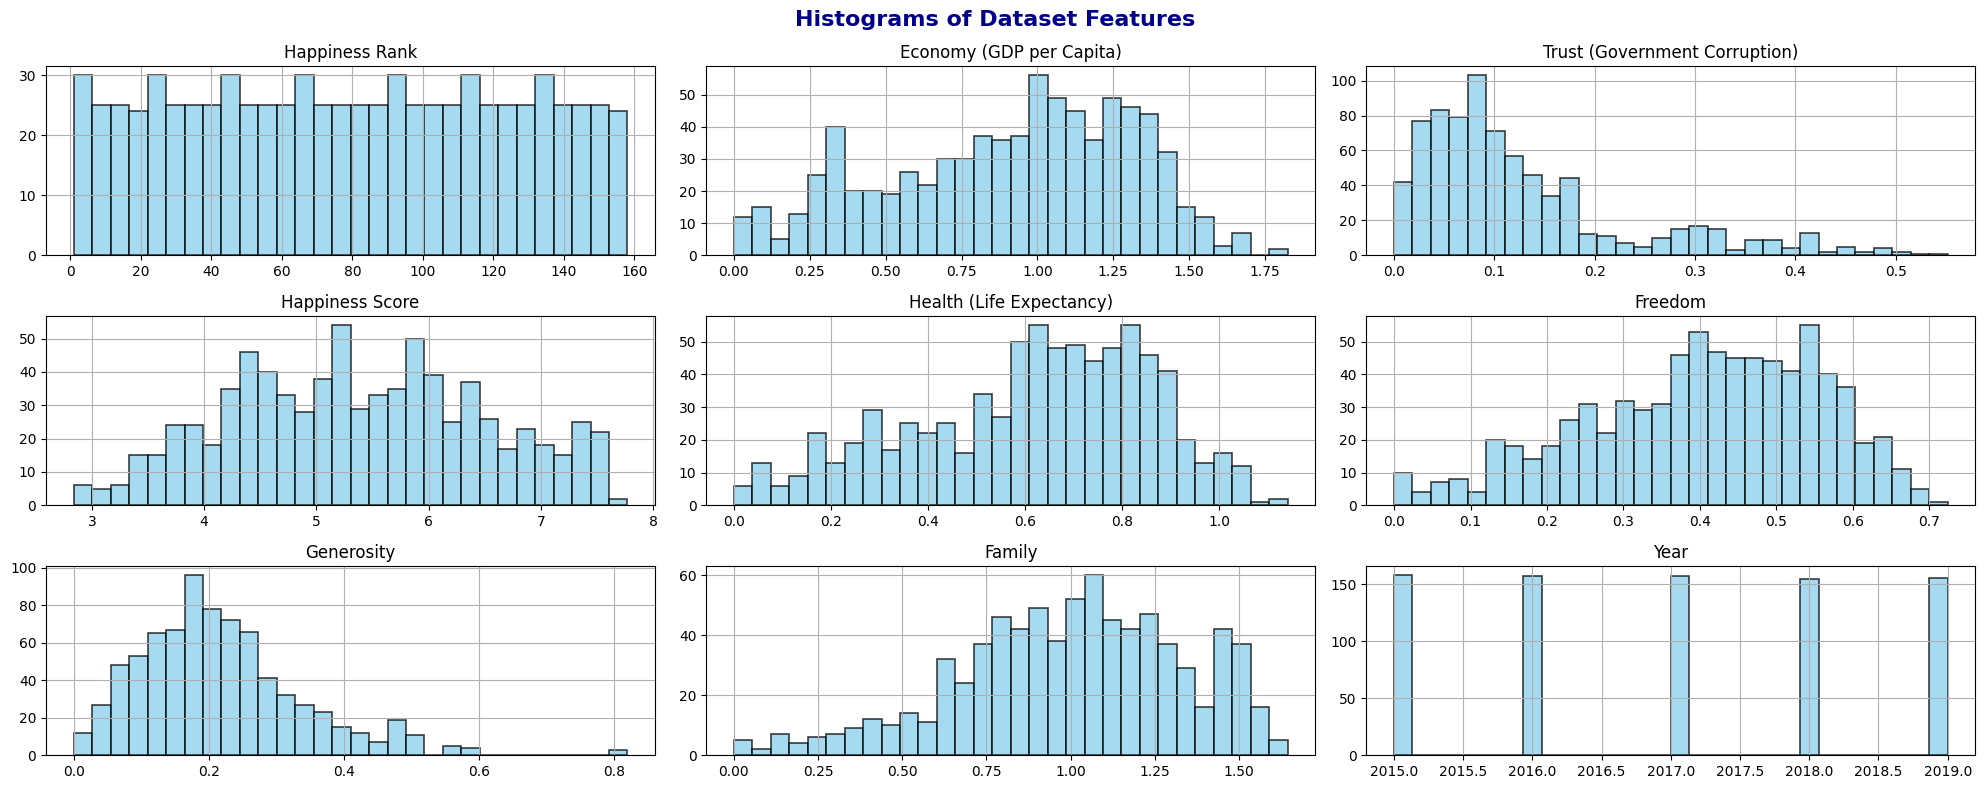

In [403]:
df_unido.hist(figsize=(20 ,8), bins=30, color="skyblue", edgecolor="black", alpha=0.75, grid=True, linewidth=1.2)
plt.suptitle("Histograms of Dataset Features", fontsize=16, fontweight="bold", color="darkblue")
plt.tight_layout()

plt.show()

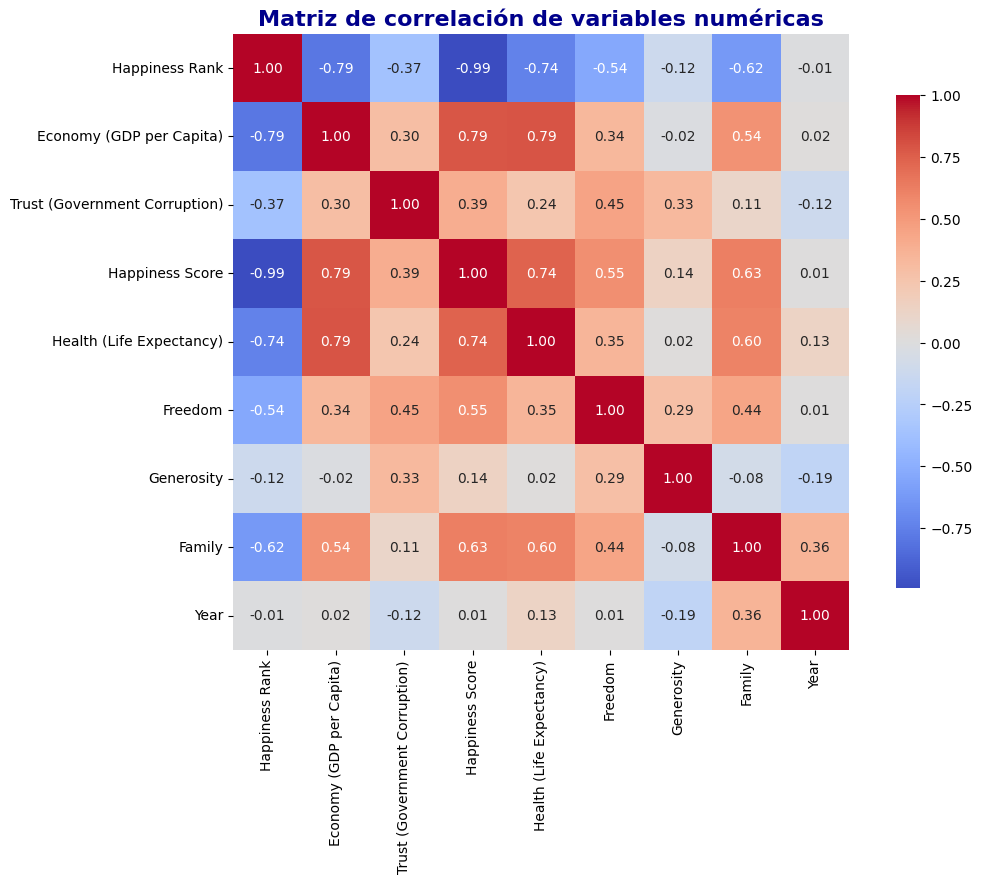

In [404]:
matrix_corre = numerical_cols.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(matrix_corre, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
plt.title("Matriz de correlación de variables numéricas", fontsize=16, fontweight="bold", color="darkblue")
plt.show()

Como vemos en el 

Se guardan los datos en csv pra depues con este csv hacer el entramoento del modelos, pero anstes vamos a aplicar OneHotEncode

In [405]:
df_encoded = pd.get_dummies(df_unido, columns=['Year'], dtype=int)

df_encoded.to_csv('../data/processed/df_clean.csv', index=False)

In [406]:
df_encoded

,Happiness Rank,Economy (GDP per Capita),Trust (Government Corruption),Happiness Score,Health (Life Expectancy),Country,Freedom,Generosity,Family,Year_2015,Year_2016,Year_2017,Year_2018,Year_2019
0,1,1.39651,0.41978,7.587,0.94143,Switzerland,0.66557,0.29678,1.34951,1,0,0,0,0
1,2,1.30232,0.14145,7.561,0.94784,Iceland,0.62877,0.43630,1.40223,1,0,0,0,0
2,3,1.32548,0.48357,7.527,0.87464,Denmark,0.64938,0.34139,1.36058,1,0,0,0,0
3,4,1.45900,0.36503,7.522,0.88521,Norway,0.66973,0.34699,1.33095,1,0,0,0,0
4,5,1.32629,0.32957,7.427,0.90563,Canada,0.63297,0.45811,1.32261,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
779,152,0.35900,0.41100,3.334,0.61400,Rwanda,0.55500,0.21700,0.71100,0,0,0,0,1
780,153,0.47600,0.14700,3.231,0.49900,Tanzania,0.41700,0.27600,0.88500,0,0,0,0,1
781,154,0.35000,0.02500,3.203,0.36100,Afghanistan,0.00000,0.15800,0.51700,0,0,0,0,1
782,155,0.02600,0.03500,3.083,0.10500,Central African Republic,0.22500,0.23500,0.00000,0,0,0,0,1


In [407]:
df_encoded.isnull().sum()

Happiness Rank                   0
Economy (GDP per Capita)         0
Trust (Government Corruption)    0
Happiness Score                  0
Health (Life Expectancy)         0
Country                          0
Freedom                          0
Generosity                       0
Family                           0
Year_2015                        0
Year_2016                        0
Year_2017                        0
Year_2018                        0
Year_2019                        0
dtype: int64

In [408]:
df_encoded.dtypes

Happiness Rank                     int64
Economy (GDP per Capita)         float64
Trust (Government Corruption)    float64
Happiness Score                  float64
Health (Life Expectancy)         float64
Country                           object
Freedom                          float64
Generosity                       float64
Family                           float64
Year_2015                          int64
Year_2016                          int64
Year_2017                          int64
Year_2018                          int64
Year_2019                          int64
dtype: object